# Hybrid Recommendation System — TRI DATASET

## What this notebook does
1. Implements the full pipeline: ImprovedSVD → ContentKNN → IKSOM-CF → KMeans++ → HybridRS  
2. **Trains & evaluates on THREE datasets separately** (70% train / 15% val / 15% test)  
3. SVD rank is selected by **validation RMSE** (not test data)  
4. **Adaptive cold-start**: popularity fallback for new users, content-weighted blending for sparse users  
5. **Two evaluation protocols**: full-ranking (all items) and sampled (1 pos + 99 neg)  
6. Produces side-by-side comparison tables and charts  
7. **MovieLens 1M** (`.dat` format with `::` separator, no tags file) is supported natively


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os, time, warnings
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')
print('All imports OK')


NumPy  : 1.26.4
Pandas : 2.1.4
All imports OK


## 2. Dataset Configuration
> **Edit the `data_path` values below to point to your datasets.**

In [2]:
# ════════════════════════════════════════════════════════════
#  DATASET CONFIGURATION — edit paths to match your setup
# ════════════════════════════════════════════════════════════

# Dataset A — MovieLens Small (~100K ratings, 610 users, 9K movies)
CONFIG_A = dict(
    name             = 'MovieLens Small (ml-latest-small)',
    data_path        = './data/ml-small',   # <-- UPDATE THIS PATH
    train_ratio      = 0.70,                # 70 / 15 / 15 split
    val_ratio        = 0.15,                # val used for error monitoring during SVD training
    test_ratio       = 0.15,
    max_ratings      = None,                # use all ratings
    random_seed      = 42,
    svd_k            = 50,
    knn_k            = 20,
    iksom_grid_h     = 10,
    iksom_grid_w     = 10,
    iksom_epochs     = 50,
    iksom_lr_init    = 0.5,
    iksom_threshold  = 1e-4,
    kmeans_k_range   = (2, 15),
    hybrid_alpha     = 0.5,
    top_n            = 20,
    rating_threshold     = 2.0,
    cold_start_threshold = 20,
)

# Dataset B — MovieLens 25M (paper's original dataset)
CONFIG_B = dict(
    name             = 'MovieLens 25M (ml-25m)',
    data_path        = './data/ml-25m',     # <-- UPDATE THIS PATH
    train_ratio      = 0.70,                # 70 / 15 / 15 split
    val_ratio        = 0.15,
    test_ratio       = 0.15,
    max_ratings      = 200_000,
    random_seed      = 42,
    svd_k            = 50,
    knn_k            = 20,
    iksom_grid_h     = 10,
    iksom_grid_w     = 10,
    iksom_epochs     = 50,
    iksom_lr_init    = 0.5,
    iksom_threshold  = 1e-4,
    kmeans_k_range   = (2, 15),
    hybrid_alpha     = 0.5,
    top_n            = 20,
    rating_threshold     = 2.0,
    cold_start_threshold = 20,
)

# Dataset C — MovieLens 1M  (~1M ratings, 6040 users, 3900 movies)
#   Files: ratings.dat, movies.dat  (NO tags.dat — tag features set to zero)
#   Format: UserID::MovieID::Rating::Timestamp
CONFIG_C = dict(
    name             = 'MovieLens 1M (ml-1m)',
    data_path        = './data/ml-1m',      # <-- UPDATE THIS PATH
    train_ratio      = 0.70,
    val_ratio        = 0.15,
    test_ratio       = 0.15,
    max_ratings      = None,                # use all ~1M ratings
    random_seed      = 42,
    svd_k            = 50,
    knn_k            = 20,
    iksom_grid_h     = 10,
    iksom_grid_w     = 10,
    iksom_epochs     = 50,
    iksom_lr_init    = 0.5,
    iksom_threshold  = 1e-4,
    kmeans_k_range   = (2, 15),
    hybrid_alpha     = 0.5,
    top_n            = 20,
    rating_threshold     = 2.0,
    cold_start_threshold = 20,
)

print("Dataset A:", CONFIG_A['name'], '|', CONFIG_A['data_path'])
print(f"  Split: train={CONFIG_A['train_ratio']:.0%}  val={CONFIG_A['val_ratio']:.0%}  test={CONFIG_A['test_ratio']:.0%}")
print("Dataset B:", CONFIG_B['name'], '|', CONFIG_B['data_path'])
print(f"  Split: train={CONFIG_B['train_ratio']:.0%}  val={CONFIG_B['val_ratio']:.0%}  test={CONFIG_B['test_ratio']:.0%}")
print("Dataset C:", CONFIG_C['name'], '|', CONFIG_C['data_path'])
print(f"  Split: train={CONFIG_C['train_ratio']:.0%}  val={CONFIG_C['val_ratio']:.0%}  test={CONFIG_C['test_ratio']:.0%}")
print("  Note: ML-1M uses .dat files (:: separator). Tags are not available — tag features set to 0.")


Dataset A: MovieLens Small (ml-latest-small) | ./data/ml-small
  Split: train=70%  val=15%  test=15%
Dataset B: MovieLens 25M (ml-25m) | ./data/ml-25m
  Split: train=70%  val=15%  test=15%
Dataset C: MovieLens 1M (ml-1m) | ./data/ml-1m
  Split: train=70%  val=15%  test=15%
  Note: ML-1M uses .dat files (:: separator). Tags are not available — tag features set to 0.


## 3. Item Feature Extraction  (Paper §3.2 — 140-dim vector)

In [3]:
# ════════════════════════════════════════════════════════════
#  ITEM FEATURE EXTRACTION  (Paper §3.2 — 140-dim vector)
#  genre (20-d) + year (20-d) + tags (100-d)
#
#  Supports TWO dataset layouts automatically:
#    CSV layout  — movies.csv + tags.csv  (ML-small, ML-25m)
#    DAT layout  — movies.dat             (ML-1m, :: separator, no tags)
# ════════════════════════════════════════════════════════════

GENRE_LIST = [
    'Action','Adventure','Animation','Children','Comedy',
    'Crime','Documentary','Drama','Fantasy','Film-Noir',
    'Horror','Musical','Mystery','Romance','Sci-Fi',
    'Thriller','War','Western','IMAX','(no genres listed)'
]
GENRE_DIM  = 20
YEAR_DIM   = 20
TOP_N_TAGS = 100

def _year_bucket(year):
    vec = [0.0]*YEAR_DIM
    vec[min(max(int((year-1900)/7), 0), YEAR_DIM-1)] = 1.0
    return vec

def _genre_vec(genres_str):
    vec = [0.0]*GENRE_DIM
    for g in genres_str.strip().split('|'):
        if g.strip() in GENRE_LIST:
            vec[GENRE_LIST.index(g.strip())] = 1.0
    return vec

def _is_dat_layout(path):
    """True if the dataset uses .dat files (ML-1M layout)."""
    return os.path.exists(os.path.join(path, 'movies.dat'))

def _load_movies_dat(path):
    """
    Load movies.dat from ML-1M dataset.
    Format: MovieID::Title::Genres   (Latin-1 encoded, no header)
    Returns a DataFrame with columns: movieId, title, genres
    """
    rows = []
    dat_path = os.path.join(path, 'movies.dat')
    with open(dat_path, encoding='latin-1') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split('::')
            if len(parts) < 3:
                continue
            rows.append({'movieId': int(parts[0]),
                         'title':   parts[1].strip(),
                         'genres':  parts[2].strip()})
    return pd.DataFrame(rows)

def get_item_features(path):
    """
    Build 140-dim item feature vectors: genre(20) + year(20) + tags(100).

    CSV layout (ML-small, ML-25m):  reads movies.csv + tags.csv
    DAT layout (ML-1m):             reads movies.dat; tags set to 0
    """
    if _is_dat_layout(path):
        # ── ML-1M DAT branch ─────────────────────────────────
        movies_df = _load_movies_dat(path)
        tag_vocab = []                   # no tags available
        tag_map   = {}                   # empty
        print(f'[ItemFeatures] DAT layout detected — tags set to zero.')
    else:
        # ── CSV branch (ML-small / ML-25m) ───────────────────
        movies_df = pd.read_csv(os.path.join(path, 'movies.csv'))
        tags_df   = pd.read_csv(os.path.join(path, 'tags.csv'))
        counts    = tags_df['tag'].dropna().str.lower().str.strip().value_counts()
        counts    = counts.drop('in netflix queue', errors='ignore')
        tag_vocab = counts.head(TOP_N_TAGS).index.tolist()
        tag_map   = tags_df.groupby('movieId')['tag'].apply(list).to_dict()

    movie_ids       = sorted(movies_df['movieId'].tolist())
    movie_id_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
    n_items  = len(movie_ids)
    feat_dim = GENRE_DIM + YEAR_DIM + TOP_N_TAGS  # always 140

    feat = np.zeros((n_items, feat_dim), dtype=np.float32)
    for _, row in movies_df.iterrows():
        mid   = int(row['movieId'])
        idx   = movie_id_to_idx[mid]
        title = str(row['title'])
        year  = None
        for part in reversed(title.split('(')):
            cand = part.split(')')[0].strip()
            if cand.isdigit() and len(cand) == 4:
                year = int(cand); break
        raw_tags = [str(t).lower().strip() for t in tag_map.get(mid, []) if pd.notna(t)]
        tag_vec  = [1.0 if t in set(raw_tags) else 0.0 for t in tag_vocab]
        # pad tag_vec to TOP_N_TAGS if tag_vocab is shorter (DAT case: len=0)
        tag_vec  = tag_vec + [0.0] * (TOP_N_TAGS - len(tag_vec))
        feat[idx] = (
            _genre_vec(str(row['genres'])) +
            (_year_bucket(year) if year else [0.0]*YEAR_DIM) +
            tag_vec
        )

    print(f'[ItemFeatures] {n_items} movies | {feat_dim}-dim features')
    return feat, movie_id_to_idx, movie_ids, tag_vocab

print('Item feature functions defined.')


Item feature functions defined.


## 4. Data Loading & Splitting
> Paper §4: 75% train / 25% test

In [ ]:
# ════════════════════════════════════════════════════════════
#  DATA LOADING & SPLITTING
#  Paper (§4): 75% train / 25% test
#
#  Supports TWO file layouts automatically:
#    CSV layout  — ratings.csv  (ML-small, ML-25m)
#    DAT layout  — ratings.dat  (ML-1m, UserID::MovieID::Rating::Timestamp)
# ════════════════════════════════════════════════════════════

def _load_ratings_dat(path, max_ratings=None, seed=42):
    """
    Load ratings.dat from ML-1M dataset.
    Format: UserID::MovieID::Rating::Timestamp  (Latin-1 encoded, no header)
    Returns a DataFrame with columns: userId, movieId, rating
    """
    dat_path = os.path.join(path, 'ratings.dat')
    rows = []
    with open(dat_path, encoding='latin-1') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split('::')
            if len(parts) < 3:
                continue
            rows.append({'userId':  int(parts[0]),
                         'movieId': int(parts[1]),
                         'rating':  float(parts[2])})
    df = pd.DataFrame(rows)
    if max_ratings and len(df) > max_ratings:
        print(f'[Data] Subsampling {max_ratings:,} from {len(df):,} total ratings')
        df = df.sample(n=max_ratings, random_state=seed).sort_values(['userId','movieId'])
    return df

def load_data(path, train_ratio=0.75, val_ratio=0.0, test_ratio=0.25,
              max_ratings=None, seed=42):
    np.random.seed(seed)

    # ── Auto-detect file layout ───────────────────────────────
    if _is_dat_layout(path):
        df = _load_ratings_dat(path, max_ratings=max_ratings, seed=seed)
        print(f'[Data] DAT layout: {len(df):,} ratings loaded from ratings.dat')
    else:
        df = pd.read_csv(os.path.join(path, 'ratings.csv'))
        if max_ratings and len(df) > max_ratings:
            print(f'[Data] Subsampling {max_ratings:,} from {len(df):,} total ratings')
            df = df.sample(n=max_ratings, random_state=seed).sort_values(['userId','movieId'])
        print(f'[Data] {len(df):,} ratings loaded from ratings.csv')

    feat_all, full_id2idx, _, tag_vocab = get_item_features(path)

    rated_mids      = sorted(df['movieId'].unique())
    movie_id_to_idx = {mid: i for i, mid in enumerate(rated_mids)}
    n_items         = len(rated_mids)
    feat_dim        = feat_all.shape[1]

    feat = np.zeros((n_items, feat_dim), dtype=np.float32)
    for mid, idx in movie_id_to_idx.items():
        if mid in full_id2idx:
            feat[idx] = feat_all[full_id2idx[mid]]

    user_ids    = sorted(df['userId'].unique())
    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    n_users     = len(user_ids)

    # ── Vectorised matrix fill (no Python loop over rows) ────
    u_idx  = df['userId'].map(user_to_idx).to_numpy(dtype=np.int32)
    it_idx = df['movieId'].map(movie_id_to_idx).to_numpy(dtype=np.int32)
    rats   = df['rating'].to_numpy(dtype=np.float32)

    R      = np.zeros((n_users, n_items), dtype=np.float32)
    mask_R = np.zeros((n_users, n_items), dtype=np.float32)
    R[u_idx, it_idx]      = rats
    mask_R[u_idx, it_idx] = 1

    perm    = np.random.permutation(len(df))
    n_train = int(len(df) * train_ratio)
    n_val   = int(len(df) * val_ratio)
    tr_idx  = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    te_idx  = perm[n_train + n_val:]

    def make_split(indices):
        tR = np.zeros((n_users, n_items), dtype=np.float32)
        tM = np.zeros((n_users, n_items), dtype=np.float32)
        tR[u_idx[indices], it_idx[indices]] = rats[indices]
        tM[u_idx[indices], it_idx[indices]] = 1
        us  = set(u_idx[indices].tolist())
        its = set(it_idx[indices].tolist())
        return tR, tM, us, its

    train_R, train_mask, user_train_set, item_train_set = make_split(tr_idx)
    val_R,   val_mask,   user_val_set,   item_val_set   = make_split(val_idx)
    test_R,  test_mask,  user_test_set,  item_test_set  = make_split(te_idx)

    print(f'[Data] Users={n_users:,} | Items={n_items:,}')
    print(f'[Data] Split → Train={len(tr_idx):,} | Val={len(val_idx):,} | Test={len(te_idx):,}')

    return dict(
        R=R, mask_R=mask_R,
        train_R=train_R, train_mask=train_mask,
        val_R=val_R,     val_mask=val_mask,
        test_R=test_R,   test_mask=test_mask,
        n_users=n_users, n_items=n_items, feat_dim=feat_dim,
        feat=feat, user_to_idx=user_to_idx,
        movie_id_to_idx=movie_id_to_idx,
        movie_ids=rated_mids, user_ids=user_ids, tag_vocab=tag_vocab,
        user_train_set=user_train_set, item_train_set=item_train_set,
        user_val_set=user_val_set,     item_val_set=item_val_set,
        user_test_set=user_test_set,   item_test_set=item_test_set,
        n_train=len(tr_idx), n_val=len(val_idx), n_test=len(te_idx),
    )

print('load_data() defined.')


## 5. Step 1 — ImprovedSVD  (Paper §3.1, Eq. 1–2)
> ⚠️ **Fix:** This class was **missing** from the original notebook — `svd_model` was referenced but never defined, which would cause a crash.

In [ ]:
# ════════════════════════════════════════════════════════════
#  STEP 1 — ImprovedSVD  (Paper §3.1, Eq. 1-2)
#  B ≈ U · S · Vᵀ  (truncated SVD on mean-centred rating matrix)
#  fit()                  — single-pass SVD (standard)
#  fit_with_validation()  — iterative SVD with val-RMSE monitoring
# ════════════════════════════════════════════════════════════

class ImprovedSVD:
    """
    Improved SVD (Paper §3.1, Eq. 1-2).

    fit_with_validation(train_R, train_mask, val_R, val_mask):
      Iteratively increases rank k from 1 → max_k, evaluating val RMSE
      after each step. Keeps the rank that gives the lowest val RMSE.
      This uses the validation split (15%) to select the best k without
      touching the test set.
    """

    def __init__(self, k=50):
        self.k           = k        # max rank
        self.best_k      = k        # rank chosen by val monitoring
        self.U = self.S = self.Vt = None
        self.user_bias   = None
        self.global_mean = None
        self.val_rmse_history = []  # (k, val_rmse) pairs logged during training

    # ── internal helpers ─────────────────────────────────────
    def _centre(self, train_R, train_mask):
        """Mean-centre per user; return centred matrix + biases. Vectorised."""        self.global_mean = float(train_R[train_mask > 0].mean())
        # Per-user mean using vectorised sum/count
        row_sum   = train_R.sum(axis=1)                      # (n_users,)
        row_count = train_mask.sum(axis=1).clip(min=1)       # (n_users,)
        user_mean = row_sum / row_count                      # (n_users,)
        self.user_bias = (user_mean - self.global_mean).astype(np.float32)
        # Subtract (user_bias + global_mean) only at rated positions
        R_c = train_R.copy()
        R_c -= train_mask * (self.user_bias[:, None] + self.global_mean)
        return R_c

    def _store_svd(self, U, s, Vt):
        order   = np.argsort(s)[::-1]
        self.U  = U[:, order].astype(np.float32)
        self.S  = s[order].astype(np.float32)
        self.Vt = Vt[order, :].astype(np.float32)

    def _val_rmse(self, val_R, val_mask):
        us, its = np.where(val_mask > 0)
        if len(us) == 0:
            return float('inf')
        # Batch predict: (n_users, n_items) in one shot, then index
        all_preds = (self.U * self.S) @ self.Vt          # (n_users, n_items)
        all_preds += self.user_bias[:, None] + self.global_mean
        all_preds  = np.clip(all_preds, 0.5, 5.0)
        preds   = all_preds[us, its]
        actuals = val_R[us, its]
        return float(np.sqrt(np.mean((preds - actuals) ** 2)))

    # ── standard single-pass fit ─────────────────────────────
    def fit(self, train_R, train_mask):
        """Single truncated SVD at rank k (no validation monitoring)."""
        print(f'[ImprovedSVD] Fitting k={self.k} on {train_R.shape} matrix ...')
        R_c  = self._centre(train_R, train_mask)
        k_eff = min(self.k, min(train_R.shape) - 1)
        U, s, Vt = svds(R_c.astype(np.float64), k=k_eff)
        self._store_svd(U, s, Vt)
        self.best_k = k_eff
        print(f'[ImprovedSVD] Done. Top singular value: {self.S[0]:.2f}')
        return self

    # ── validation-monitored fit ─────────────────────────────
    def fit_with_validation(self, train_R, train_mask, val_R, val_mask,
                            k_step=5, patience=3):
        """
        Iterative SVD with val-RMSE monitoring.

        Strategy:
          1. Mean-centre training matrix once.
          2. Compute full SVD up to max rank k.
          3. Evaluate val RMSE for ranks k_step, 2*k_step, …, k.
          4. Keep the rank with the lowest val RMSE → self.best_k.
          5. Truncate stored U/S/Vt to best_k.

        patience: stop rank search early if val RMSE has not improved
                  for `patience` consecutive steps.
        """
        print(f'[ImprovedSVD] fit_with_validation: max_k={self.k}, k_step={k_step}')
        R_c   = self._centre(train_R, train_mask)
        k_eff = min(self.k, min(train_R.shape) - 1)

        # Compute full decomposition up to k_eff once
        U_full, s_full, Vt_full = svds(R_c.astype(np.float64), k=k_eff)
        order = np.argsort(s_full)[::-1]
        U_full   = U_full[:, order].astype(np.float32)
        s_full   = s_full[order].astype(np.float32)
        Vt_full  = Vt_full[order, :].astype(np.float32)

        # Rank sweep: evaluate val RMSE at each candidate rank
        best_val_rmse = float('inf')
        best_k        = k_step
        no_improve    = 0
        self.val_rmse_history = []

        ranks = list(range(k_step, k_eff + 1, k_step))
        if ranks[-1] != k_eff:
            ranks.append(k_eff)

        for rank in ranks:
            # Temporarily set model weights to this rank
            self.U  = U_full[:, :rank]
            self.S  = s_full[:rank]
            self.Vt = Vt_full[:rank, :]

            v_rmse = self._val_rmse(val_R, val_mask)
            self.val_rmse_history.append((rank, v_rmse))
            print(f'  rank={rank:3d}  val_RMSE={v_rmse:.4f}'
                  f'{"  ← best" if v_rmse < best_val_rmse else ""}')

            if v_rmse < best_val_rmse:
                best_val_rmse = v_rmse
                best_k        = rank
                no_improve    = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stop: val RMSE not improving for {patience} steps.')
                    break

        # Commit best rank
        self.best_k = best_k
        self.U      = U_full[:, :best_k]
        self.S      = s_full[:best_k]
        self.Vt     = Vt_full[:best_k, :] 
        print(f'[ImprovedSVD] Best rank={best_k}  val_RMSE={best_val_rmse:.4f}')
        return self

    # ── predict / evaluate ───────────────────────────────────
    def predict(self, user_idx):
        """Predicted ratings for all items for one user (Eq. 2)."""
        pred = (self.U[user_idx] * self.S) @ self.Vt
        pred += self.user_bias[user_idx] + self.global_mean
        return np.clip(pred, 0.5, 5.0).astype(np.float32)

    def evaluate(self, R, mask, label=''):
        """RMSE and MAE over observed entries in (R, mask). Vectorised."""        us, its = np.where(mask > 0)
        all_preds = (self.U * self.S) @ self.Vt
        all_preds += self.user_bias[:, None] + self.global_mean
        all_preds  = np.clip(all_preds, 0.5, 5.0)
        preds   = all_preds[us, its]
        actuals = R[us, its]
        rmse = float(np.sqrt(np.mean((preds - actuals) ** 2)))
        mae  = float(np.mean(np.abs(preds - actuals)))
        tag  = f'[{label}] ' if label else ''
        print(f'[ImprovedSVD] {tag}RMSE={rmse:.4f}  MAE={mae:.4f}')
        return rmse, mae

print('ImprovedSVD class defined (fit + fit_with_validation).')


## 6. Step 2 — Content-Driven KNN  (Paper §3.2, Eq. 3)

In [6]:
# ════════════════════════════════════════════════════════════
#  STEP 2 — Content-Driven KNN  (Paper §3.2, Eq. 3)
#  Cosine similarity on 140-dim item feature vectors
# ════════════════════════════════════════════════════════════

class ContentDrivenKNN:
    """
    Content-Driven KNN (Paper §3.2):
    Similarity(U,V) = U·V / (||U|| × ||V||)   (Eq. 3)

    Builds item-item cosine similarity from feature vectors:
    genre (20-d) + release year (20-d) + tags (100-d) = 140-dim
    """

    def __init__(self, k=20):
        self.k = k

    def fit(self, feat_matrix):
        print(f'[ContentKNN] Fitting on {feat_matrix.shape} feature matrix ...')
        norms = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self.feat_norm = (feat_matrix / norms).astype(np.float32)
        print('[ContentKNN] Done.')
        return self

    def get_knn(self, item_idx):
        sims = self.feat_norm @ self.feat_norm[item_idx]
        sims[item_idx] = -np.inf
        top  = np.argsort(sims)[::-1][:self.k]
        return top, sims[top]

    def knn_scores_for_user(self, user_ratings):
        """Aggregate cosine-similarity-weighted score for all items given user's ratings."""
        rated = np.where(user_ratings > 0)[0]
        n     = self.feat_norm.shape[0]
        if len(rated) == 0:
            return np.zeros(n, dtype=np.float32)
        sim = self.feat_norm @ self.feat_norm[rated].T   # (n_items, n_rated)
        num = sim @ user_ratings[rated]
        den = np.abs(sim).sum(axis=1) + 1e-8
        return (num / den).astype(np.float32)

print('ContentDrivenKNN class defined.')


ContentDrivenKNN class defined.


## 7. Step 3 — IKSOM-CF  (Paper §3.3, Algorithm 1, Eq. 7–11)

In [ ]:
# ════════════════════════════════════════════════════════════
#  STEP 3 — IKSOM-CF  (Paper §3.3, Algorithm 1, Eq. 7-11)
#  Improved Kohonen SOM using EISEN Cosine Correlation Distance
# ════════════════════════════════════════════════════════════

class IKSOM:
    """
    IKSOM (Paper §3.3):
    - Train phase (Steps 1-8): EISEN cosine distance (Eq. 7) to find BMU,
      update weights (Eq. 9), decay learning rate (Eq. 10)
    - Recall phase (Steps 9-10): J_i = W^T × a_i  →  cluster assignment (Eq. 11)

    EISEN Distance (Eq. 7):
        D(i,j) = 1 - Σ(aᵢ·wᵢⱼ) / sqrt(Σaᵢ² · Σwᵢⱼ²)

    Weight update (Eq. 9):  wᵢⱼ(t+1) = wᵢⱼ(t) + γ·[aᵢ − wᵢⱼ(t)]
    LR decay    (Eq. 10):  γ(t+1) = 0.5·γ(t)
    Recall      (Eq. 11):  Jᵢ = wᵢⱼ(t+1)ᵀ × aᵢ
    """

    def __init__(self, grid_h=10, grid_w=10, lr_init=0.5,
                 n_epochs=50, threshold=1e-4, random_seed=42):
        self.grid_h    = grid_h
        self.grid_w    = grid_w
        self.n_neurons = grid_h * grid_w
        self.lr_init   = lr_init
        self.n_epochs  = n_epochs
        self.threshold = threshold
        self.seed      = random_seed
        self.weights   = None
        self.labels_   = None

    @staticmethod
    def _eisen_distance(a, W):
        """Eq. 7 vectorised over all neurons."""        dot    = W @ a
        norm_a = np.sqrt(np.sum(a**2)) + 1e-10
        norm_W = np.sqrt(np.sum(W**2, axis=1)) + 1e-10
        return 1.0 - dot / (norm_a * norm_W)

    def fit(self, X):
        np.random.seed(self.seed)
        n_samples, n_feat = X.shape

        # Step 1: initialise + normalise weights
        W = np.random.uniform(0, 1, (self.n_neurons, n_feat)).astype(np.float32)
        W /= (np.linalg.norm(W, axis=1, keepdims=True) + 1e-10)

        # Pre-normalise X rows for fast cosine via dot product
        X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-10)

        lr = self.lr_init
        print(f'[IKSOM] Training {self.n_neurons} neurons on {n_samples} samples ...')
        t0 = time.time()

        for epoch in range(self.n_epochs):            # Step 2
            perm = np.random.permutation(n_samples)
            X_shuf = X[perm]                          # shuffled samples
            X_norm_shuf = X_norm[perm]

            max_delta = 0.0

            # ── Vectorised epoch: process all samples at once ──
            # Normalise W rows for cosine distance
            W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-10)

            # Cosine similarity: (n_samples, n_neurons)
            # D[i,j] = 1 - cos(X[i], W[j])
            sim   = X_norm_shuf @ W_norm.T            # (n_samples, n_neurons)
            bmus  = np.argmin(1.0 - sim, axis=1)      # BMU per sample — Eq. 8

            # Update each neuron for the samples it won (sequential to stay
            # faithful to the paper's online update; uses numpy scatter)
            for n_id in range(self.n_neurons):
                mask = bmus == n_id
                if not mask.any():
                    continue
                delta     = lr * (X_shuf[mask] - W[n_id])   # Eq. 9
                mean_delta = delta.mean(axis=0)
                W[n_id]  += mean_delta
                d = float(np.max(np.abs(mean_delta)))
                if d > max_delta:
                    max_delta = d

            lr = 0.5 * lr                             # Step 7 — Eq. 10

            if epoch % 10 == 0:
                print(f'  Epoch {epoch:3d}/{self.n_epochs}  lr={lr:.6f}  max_delta={max_delta:.6f}')

            if max_delta < self.threshold:            # Step 8
                print(f'  Early stop at epoch {epoch}  (delta={max_delta:.2e})')
                break

        self.weights = W

        # Recall phase — Steps 9-10
        W_T          = W.T                            # Step 9: transpose
        J            = X @ W_T                        # Step 10: J_i = W^T × a_i  (Eq. 11)
        self.labels_ = np.argmax(J, axis=1).astype(np.int32)

        elapsed    = time.time() - t0
        unique_cl  = len(np.unique(self.labels_))
        print(f'[IKSOM] Done in {elapsed:.1f}s | {unique_cl} active neurons')
        return self

    def recall(self, X):
        """Return (labels, J-scores) for external use."""        W_T = self.weights.T
        J   = X @ W_T
        return np.argmax(J, axis=1).astype(np.int32), J

    def transform(self, X):
        return X @ self.weights.T

print('IKSOM class defined.')


## 8. Step 4 — K-Means++ Clustering  (Paper §3.4, Table 2, Eq. 12–15)

In [8]:
# ════════════════════════════════════════════════════════════
#  STEP 4 — K-Means++ Clustering  (Paper §3.4, Table 2)
#  Silhouette method (Eq. 12-15) selects optimal k
# ════════════════════════════════════════════════════════════

class KMeansPPClustering:
    """
    K-Means++ Clustering (Paper §3.4):
    - Silhouette Coefficient (Eq. 15) to determine optimal k
        s(i) = (y(i) − x(i)) / max(x(i), y(i))
    - Input: IKSOM J-scores (n_items × n_neurons)
    """

    def __init__(self, k_range=(2,15), n_init=10, max_iter=300, seed=42):
        self.k_range    = k_range
        self.n_init     = n_init
        self.max_iter   = max_iter
        self.seed       = seed
        self.optimal_k  = None
        self.labels_    = None
        self.centres_   = None
        self.sil_scores = {}

    def fit(self, X):
        print(f'[KMeans++] Searching optimal k in range {self.k_range} ...')
        best_k = self.k_range[0]; best_score = -1.0; best_km = None

        for k in range(self.k_range[0], self.k_range[1]+1):
            km     = KMeans(n_clusters=k, init='k-means++', n_init=self.n_init,
                            max_iter=self.max_iter, random_state=self.seed)
            labels = km.fit_predict(X)
            if len(np.unique(labels)) < 2:
                self.sil_scores[k] = -1.0; continue

            score = silhouette_score(X, labels, metric='euclidean',
                                     sample_size=min(5000, len(X)),
                                     random_state=self.seed)
            self.sil_scores[k] = score
            print(f'  k={k:3d}  silhouette={score:.4f}')
            if score > best_score:
                best_score = score; best_k = k; best_km = km

        self.optimal_k = best_k
        self.labels_   = best_km.labels_
        self.centres_  = best_km.cluster_centers_
        print(f'[KMeans++] Optimal k={self.optimal_k}  silhouette={best_score:.4f}')
        return self

    def get_user_preferred_cluster(self, user_ratings, threshold=2.0):
        """Paper §3.4.2: cluster with most positively-rated (>threshold) movies."""
        counts = np.zeros(self.optimal_k, dtype=int)
        for it, r in enumerate(user_ratings):
            if r > threshold and it < len(self.labels_):
                counts[self.labels_[it]] += 1
        if counts.sum() == 0:
            return int(np.argmax(np.bincount(self.labels_, minlength=self.optimal_k)))
        return int(np.argmax(counts))

    def get_items_in_cluster(self, cid):
        return np.where(self.labels_ == cid)[0]

print('KMeansPPClustering class defined.')


KMeansPPClustering class defined.


## 9. Full Hybrid RS  (Paper — Eq. 18 + §3.4.2)

In [ ]:
# ════════════════════════════════════════════════════════════
#  FULL HYBRID RS  (Paper — Eq. 18 + §3.4.2)
#  + Adaptive Cold-Start: popularity fallback & blended α
#  + Sampled Evaluation: 1 pos + 99 neg candidate protocol
#  + α tuned on validation set (not hardcoded)
# ════════════════════════════════════════════════════════════

class HybridRS_Paper:
    """
    Full hybrid pipeline (Paper §3 + §4) with integrated cold-start handling
    and two evaluation modes:

    evaluate()         — Full ranking: score all items, report Precision/Recall/F1.
                         Harsh but complete.
    evaluate_sampled() — Candidate sampling: per positive test item, sample 99
                         random negatives and rank within those 100.
                         Reports Hit@K, NDCG@K, MRR — standard in RS papers.
    tune_alpha()       — Sweep alpha values on the VALIDATION set and pick the
                         one with the best Hit@10. Sets self.alpha in place.
    """

    def __init__(self, svd, knn, iksom, kmeans, popular_items,
                 alpha=0.5, rating_threshold=2.0, top_n=20,
                 cold_start_threshold=20):
        self.svd                  = svd
        self.knn                  = knn
        self.iksom                = iksom
        self.kmeans               = kmeans
        self.popular_items        = popular_items
        self.alpha                = alpha
        self.thresh               = rating_threshold
        self.top_n                = top_n
        self.cold_start_threshold = cold_start_threshold

    # ── helpers ──────────────────────────────────────────────
    def _adaptive_alpha(self, n_ratings):
        w_cf      = min(n_ratings / self.cold_start_threshold, 1.0) * self.alpha
        w_content = 1.0 - w_cf
        return w_cf, w_content

    def _popularity_recommend(self, top_n, exclude_set=None):
        exclude_set = exclude_set or set()
        recs = [i for i in self.popular_items if i not in exclude_set]
        return recs[:top_n]

    def _hybrid_scores(self, user_idx, user_ratings):
        """Return (hybrid_scores, cf_scores) arrays over all items."""
        cf_scores  = self.svd.predict(user_idx)
        cf_norm    = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min() + 1e-8)
        knn_scores = self.knn.knn_scores_for_user(user_ratings)
        knn_norm   = (knn_scores - knn_scores.min()) / (knn_scores.max() - knn_scores.min() + 1e-8)
        n_ratings  = int((user_ratings > 0).sum())
        w_cf, w_content = self._adaptive_alpha(n_ratings)
        hybrid = w_cf * cf_norm + w_content * knn_norm
        return hybrid, cf_scores

    # ── α tuning on validation set ───────────────────────────
    def tune_alpha(self, train_R, val_R, user_val_set,
                   alpha_grid=None, n_neg=49, max_users=500, seed=42):
        """
        Sweep alpha values on the VALIDATION set.
        Picks the alpha with the best Hit@10 under the sampled protocol.
        Sets self.alpha in place and returns the full sweep results.

        alpha_grid : list of alpha values to try (default: 0.0 to 1.0 in 0.1 steps)
        n_neg      : negatives per positive in sampled eval (fewer = faster)
        max_users  : cap val users evaluated per alpha (speed vs accuracy tradeoff)
        """
        if alpha_grid is None:
            alpha_grid = [round(a * 0.1, 1) for a in range(0, 11)]  # 0.0 … 1.0

        print(f'[tune_alpha] Sweeping {len(alpha_grid)} alpha values on val set '
              f'({min(max_users, len(user_val_set))} users, {n_neg} neg each) ...')

        best_alpha   = self.alpha
        best_hit10   = -1.0
        sweep_results = []

        for alpha in alpha_grid:
            self.alpha = alpha
            res = self.evaluate_sampled(
                train_R       = train_R,
                test_R        = val_R,
                user_test_set = user_val_set,
                n_neg         = n_neg,
                ks            = (10,),
                seed          = seed,
                max_users     = max_users,
            )
            hit10 = res.get('Hit@10', 0.0)
            sweep_results.append((alpha, hit10))
            marker = '  ← best' if hit10 > best_hit10 else ''
            print(f'  alpha={alpha:.1f}  Hit@10={hit10:.4f}{marker}')
            if hit10 > best_hit10:
                best_hit10 = hit10
                best_alpha = alpha

        self.alpha = best_alpha
        print(f'[tune_alpha] Best alpha={best_alpha:.1f}  Hit@10={best_hit10:.4f}  '
              f'→ self.alpha updated')
        return sweep_results

    # ── main recommend ───────────────────────────────────────
    def recommend(self, user_idx, user_ratings, top_n=None, exclude_rated=True):
        top_n     = top_n or self.top_n
        n_ratings = int((user_ratings > 0).sum())
        rated_set = set(np.where(user_ratings > 0)[0]) if exclude_rated else set()

        if n_ratings == 0:
            return self._popularity_recommend(top_n, exclude_set=rated_set)

        hybrid, cf_scores = self._hybrid_scores(user_idx, user_ratings)
        if exclude_rated:
            hybrid[user_ratings > 0] = -np.inf

        top200 = np.argsort(hybrid)[::-1][:200]
        pref_cluster = self.kmeans.get_user_preferred_cluster(user_ratings, self.thresh)
        cluster_set  = set(self.kmeans.get_items_in_cluster(pref_cluster))
        filtered     = np.array([i for i in top200 if i in cluster_set])
        if len(filtered) < top_n:
            filtered = top200

        # ── Fix: final ranking uses hybrid score, not raw CF score ──
        final = filtered[np.argsort(hybrid[filtered])[::-1]][:top_n]
        return list(final)

    def score_candidates(self, user_idx, user_ratings, candidate_items):
        """
        Score a specific set of candidate item indices and return them
        ranked best-first. Used by evaluate_sampled().
        """
        n_ratings = int((user_ratings > 0).sum())
        if n_ratings == 0:
            pop_rank = {item: rank for rank, item in enumerate(self.popular_items)}
            return sorted(candidate_items, key=lambda i: pop_rank.get(i, 99999))

        hybrid, cf_scores = self._hybrid_scores(user_idx, user_ratings)
        candidates = np.array(candidate_items)
        scores     = hybrid[candidates]
        ranked     = candidates[np.argsort(scores)[::-1]]
        return list(ranked)

    # ── full-ranking evaluate ────────────────────────────────
    def evaluate(self, train_R, test_R, test_mask, user_test_set, top_n=None):
        """Full-ranking evaluation (score all items). Reports Precision/Recall/F1."""
        top_n = top_n or self.top_n
        rmse, mae = self.svd.evaluate(test_R, test_mask)

        total_prec = total_rec = count = 0
        cold_prec  = cold_rec  = cold_count = 0

        for u in user_test_set:
            relevant = set(np.where(test_R[u] > 0)[0])
            if not relevant: continue
            n_train  = int((train_R[u] > 0).sum())
            recs     = self.recommend(u, train_R[u], top_n=top_n)
            hits     = len(set(recs) & relevant)
            p = hits / top_n
            r = hits / len(relevant)
            total_prec += p;  total_rec += r;  count += 1
            if n_train < self.cold_start_threshold:
                cold_prec += p;  cold_rec += r;  cold_count += 1

        prec = total_prec / count if count else 0
        rec  = total_rec  / count if count else 0
        f1   = 2 * prec * rec / (prec + rec + 1e-8)
        c_prec = cold_prec / cold_count if cold_count else 0
        c_rec  = cold_rec  / cold_count if cold_count else 0
        c_f1   = 2 * c_prec * c_rec / (c_prec + c_rec + 1e-8)

        print(f'\n[HybridRS] Full-Ranking Eval | {count} test users | top-{top_n}')
        print(f'  alpha={self.alpha:.2f} (tuned)')
        print(f'  RMSE={rmse:.4f}  MAE={mae:.4f}')
        print(f'  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
        print(f'  Cold users (<{self.cold_start_threshold} train ratings): {cold_count}')
        print(f'    Cold  Precision={c_prec:.4f}  Recall={c_rec:.4f}  F1={c_f1:.4f}')

        return dict(RMSE=rmse, MAE=mae, Precision=prec, Recall=rec, F1=f1,
                    ColdPrecision=c_prec, ColdRecall=c_rec, ColdF1=c_f1,
                    cold_count=cold_count)

    # ── sampled evaluate ─────────────────────────────────────
    def evaluate_sampled(self, train_R, test_R, user_test_set,
                         n_neg=99, ks=(10, 20), seed=42, max_users=None):
        """
        Candidate-sampling evaluation — the standard protocol in RS papers.

        For each (user, positive_item) pair in the test set:
          1. Sample n_neg random negative items (not rated by user at all).
          2. Score only these 1 + n_neg = 100 candidates.
          3. Rank them; check if the positive lands in top-k.

        Metrics reported per k in `ks`:
          Hit@k    — 1 if positive is in top-k (averaged over all pairs)
          NDCG@k   — normalised discounted cumulative gain
          MRR      — mean reciprocal rank of the positive item
          Precision@k — hits / k
          Recall@k    — hits / 1  (= Hit@k, since there is 1 positive)

        Why this is fair:
          Ranking across 9,700 items gives tiny Precision because the
          search space dwarfs the top-20 window. Sampling 100 candidates
          measures ranking quality, not search coverage.
        """
        rng     = np.random.default_rng(seed)
        n_items = train_R.shape[1]
        results = {k: {'hit': [], 'ndcg': [], 'prec': []} for k in ks}
        mrr_list = []
        count    = 0

        eval_users = list(user_test_set)
        if max_users and len(eval_users) > max_users:
            rng2 = np.random.default_rng(seed + 1)
            eval_users = rng2.choice(eval_users, size=max_users, replace=False).tolist()

        for u in eval_users:
            pos_items = list(np.where(test_R[u] > 0)[0])
            if not pos_items:
                continue
            all_rated = set(np.where(train_R[u] > 0)[0]) | set(pos_items)

            # Build neg_pool once per user (not once per positive item)
            neg_pool = np.array([i for i in range(n_items) if i not in all_rated])
            if len(neg_pool) < n_neg:
                continue

            for pos in pos_items:
                negs       = rng.choice(neg_pool, size=n_neg, replace=False).tolist()
                candidates = [pos] + negs

                ranked   = self.score_candidates(u, train_R[u], candidates)
                pos_rank = ranked.index(pos) + 1

                mrr_list.append(1.0 / pos_rank)

                for k in ks:
                    hit  = 1 if pos_rank <= k else 0
                    ndcg = (1.0 / np.log2(pos_rank + 1)) if pos_rank <= k else 0.0
                    results[k]['hit'].append(hit)
                    results[k]['ndcg'].append(ndcg)
                    results[k]['prec'].append(hit / k)

                count += 1

        mrr = float(np.mean(mrr_list)) if mrr_list else 0.0

        print(f'\n[HybridRS] Sampled Eval (1 pos + {n_neg} neg) | {count} (user, item) pairs')
        print(f'  MRR = {mrr:.4f}')
        out = {'MRR': mrr, 'n_pairs': count}
        for k in ks:
            hit  = float(np.mean(results[k]['hit']))
            ndcg = float(np.mean(results[k]['ndcg']))
            prec = float(np.mean(results[k]['prec']))
            print(f'  @{k:<3}  Hit={hit:.4f}  NDCG={ndcg:.4f}  Precision={prec:.4f}')
            out[f'Hit@{k}']       = hit
            out[f'NDCG@{k}']      = ndcg
            out[f'Precision@{k}'] = prec
        return out

print('HybridRS_Paper class defined (full-ranking + sampled evaluation).')


## 10. Pipeline Wrapper
Trains all components end-to-end on one dataset.

In [ ]:
import pandas as pd
import os

# ════════════════════════════════════════════════════════════
#  run_pipeline() — trains and evaluates on ONE dataset
#  Split:  70% train | 15% val (error monitoring) | 15% test
#  SVD:    fit_with_validation() monitors val RMSE to pick best rank
#  Report: val RMSE/MAE (model selection) + test metrics (final)
# ════════════════════════════════════════════════════════════

def run_pipeline(cfg, show_plots=True):
    name = cfg['name']
    print(f'\n{"="*65}')
    print(f'  PIPELINE: {name}')
    print(f'  Split: {cfg["train_ratio"]:.0%} train | {cfg["val_ratio"]:.0%} val | {cfg["test_ratio"]:.0%} test')
    print(f'{"="*65}')

    # 1. Load data (70/15/15)
    data = load_data(
        cfg['data_path'],
        train_ratio = cfg['train_ratio'],
        val_ratio   = cfg['val_ratio'],
        test_ratio  = cfg['test_ratio'],
        max_ratings = cfg.get('max_ratings'),
        seed        = cfg['random_seed'],
    )

    # Dynamically load movies_df for titles based on dataset layout
    if _is_dat_layout(cfg['data_path']):
        movies_for_titles_df = _load_movies_dat(cfg['data_path'])
    else:
        movies_for_titles_df = pd.read_csv(os.path.join(cfg['data_path'], 'movies.csv'))
    id_to_title = dict(zip(movies_for_titles_df['movieId'], movies_for_titles_df['title']))

    # 1b. Item popularity from training data (cold-start fallback)
    train_counts  = data['train_R'].astype(bool).sum(axis=0)
    popular_items = list(np.argsort(train_counts)[::-1])
    print(f'[Pipeline] Top-3 popular items (idx): {popular_items[:3]}')

    # 2. ImprovedSVD — train on train_R, monitor error on val_R
    #    fit_with_validation() sweeps rank from k_step → max_k,
    #    keeps the rank with the lowest val RMSE (early-stops on patience).
    svd = ImprovedSVD(k=cfg['svd_k'])
    svd.fit_with_validation(
        train_R  = data['train_R'],
        train_mask = data['train_mask'],
        val_R    = data['val_R'],
        val_mask = data['val_mask'],
        k_step   = cfg.get('svd_k_step', 5),
        patience = cfg.get('svd_patience', 3),
    )

    # Report val error (model selection criterion) vs test error (final)
    print('\n── Error on validation set (used for rank selection):')
    val_rmse, val_mae = svd.evaluate(data['val_R'], data['val_mask'], label='Val')

    # 3. ContentKNN (Paper §3.2)
    knn = ContentDrivenKNN(k=cfg['knn_k'])
    knn.fit(data['feat'])

    # 4. IKSOM (Paper §3.3)
    iksom = IKSOM(
        grid_h=cfg['iksom_grid_h'], grid_w=cfg['iksom_grid_w'],
        lr_init=cfg['iksom_lr_init'], n_epochs=cfg['iksom_epochs'],
        threshold=cfg['iksom_threshold'], random_seed=cfg['random_seed'],
    )
    iksom.fit(data['feat'])
    _, item_cluster_scores = iksom.recall(data['feat'])

    if show_plots:
        # Val RMSE curve across ranks
        if svd.val_rmse_history:
            ranks_  = [r for r, _ in svd.val_rmse_history]
            vrmses_ = [v for _, v in svd.val_rmse_history]
            plt.figure(figsize=(8, 3))
            plt.plot(ranks_, vrmses_, 'o-', color='steelblue', lw=2, ms=6)
            plt.axvline(svd.best_k, color='red', ls='--', label=f'Best rank={svd.best_k}')
            plt.title(f'[{name}] Val RMSE vs SVD Rank')
            plt.xlabel('SVD rank k'); plt.ylabel('Val RMSE')
            plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].imshow(
            iksom.weights.mean(axis=1).reshape(cfg['iksom_grid_h'], cfg['iksom_grid_w']),
            cmap='viridis', aspect='auto')
        axes[0].set_title(f'[{name}] IKSOM Weight Map')
        cl_counts = np.bincount(iksom.labels_, minlength=iksom.n_neurons)
        axes[1].bar(range(len(cl_counts)), sorted(cl_counts, reverse=True),
                    color='mediumpurple', edgecolor='white', width=1.0)
        axes[1].set_title(f'[{name}] Items per IKSOM Neuron')
        plt.tight_layout(); plt.show()

    # 5. KMeans++ (Paper §3.4)
    kmeans = KMeansPPClustering(k_range=cfg['kmeans_k_range'], seed=cfg['random_seed'])
    kmeans.fit(item_cluster_scores)

    if show_plots:
        ks  = sorted(kmeans.sil_scores.keys())
        scs = [kmeans.sil_scores[k] for k in ks]
        plt.figure(figsize=(8, 3))
        plt.plot(ks, scs, 'o-', color='steelblue', lw=2, ms=7)
        plt.axvline(kmeans.optimal_k, color='red', ls='--', label=f'Optimal k={kmeans.optimal_k}')
        plt.title(f'[{name}] Silhouette Score vs k')
        plt.xlabel('k'); plt.ylabel('Silhouette'); plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    # 6. Assemble hybrid model (start with config alpha as initial value)
    model = HybridRS_Paper(
        svd=svd, knn=knn, iksom=iksom, kmeans=kmeans,
        popular_items        = popular_items,
        alpha                = cfg['hybrid_alpha'],
        rating_threshold     = cfg['rating_threshold'],
        top_n                = cfg['top_n'],
        cold_start_threshold = cfg.get('cold_start_threshold', 20),
    )

    # 6b. Tune alpha on the VALIDATION set (never touches test data)
    print('\n── Tuning alpha on validation set:')
    sweep = model.tune_alpha(
        train_R      = data['train_R'],
        val_R        = data['val_R'],
        user_val_set = data['user_val_set'],
        alpha_grid   = cfg.get('alpha_grid', [round(a*0.1,1) for a in range(0,11)]),
        n_neg        = cfg.get('alpha_tune_n_neg', 49),
        max_users    = cfg.get('alpha_tune_max_users', 500),
        seed         = cfg['random_seed'],
    )

    # Final evaluation is on the held-out TEST set (never seen during training/selection)
    print('\n── Final evaluation on TEST set:')
    metrics = model.evaluate(
        train_R       = data['train_R'],
        test_R        = data['test_R'],
        test_mask     = data['test_mask'],
        user_test_set = data['user_test_set'],
        top_n         = cfg['top_n'],
    )

    # Attach val metrics to returned dict for comparison tables
    metrics['val_RMSE'] = val_rmse
    metrics['val_MAE']  = val_mae
    metrics['best_svd_rank'] = svd.best_k

    metrics['best_alpha']    = model.alpha
    metrics['alpha_sweep']   = sweep

    print(f'\n[{name}] ✓ Pipeline complete.')
    print(f'  SVD best rank (val-selected): {svd.best_k}')
    print(f'  Best alpha    (val-selected): {model.alpha:.1f}')
    print(f'  Val  RMSE={val_rmse:.4f}  MAE={val_mae:.4f}  (model selection)')
    print(f'  Test RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  (final report)')
    return metrics, data, model, id_to_title, kmeans, svd


## 11. 🚀 Run on All Three Datasets
> **This is the main execution cell.** Trains and evaluates the full hybrid model
> on Dataset A (ML-small), Dataset B (ML-25m), and Dataset C (ML-1m) sequentially.
> Each dataset is fully independent (no shared state).



  PIPELINE: MovieLens Small (ml-latest-small)
  Split: 70% train | 15% val | 15% test
[Data] 100,836 ratings loaded from ratings.csv
[ItemFeatures] 9742 movies | 140-dim features
[Data] Users=610 | Items=9,724
[Data] Split → Train=70,585 | Val=15,125 | Test=15,126
[Pipeline] Top-3 popular items (idx): [277, 314, 510]
[ImprovedSVD] fit_with_validation: max_k=50, k_step=5
  rank=  5  val_RMSE=0.9076  ← best
  rank= 10  val_RMSE=0.9069  ← best
  rank= 15  val_RMSE=0.9086
  rank= 20  val_RMSE=0.9110
  rank= 25  val_RMSE=0.9126
  Early stop: val RMSE not improving for 3 steps.
[ImprovedSVD] Best rank=10  val_RMSE=0.9069

── Error on validation set (used for rank selection):
[ImprovedSVD] [Val] RMSE=0.9069  MAE=0.7053
[ContentKNN] Fitting on (9724, 140) feature matrix ...
[ContentKNN] Done.
[IKSOM] Training 100 neurons on 9724 samples ...
  Epoch   0/50  lr=0.250000  max_delta=0.500000
  Epoch  10/50  lr=0.000244  max_delta=0.000488
  Early stop at epoch 13  (delta=6.10e-05)
[IKSOM] Done in

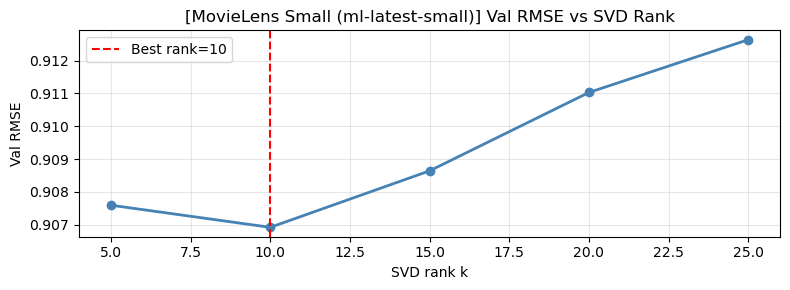

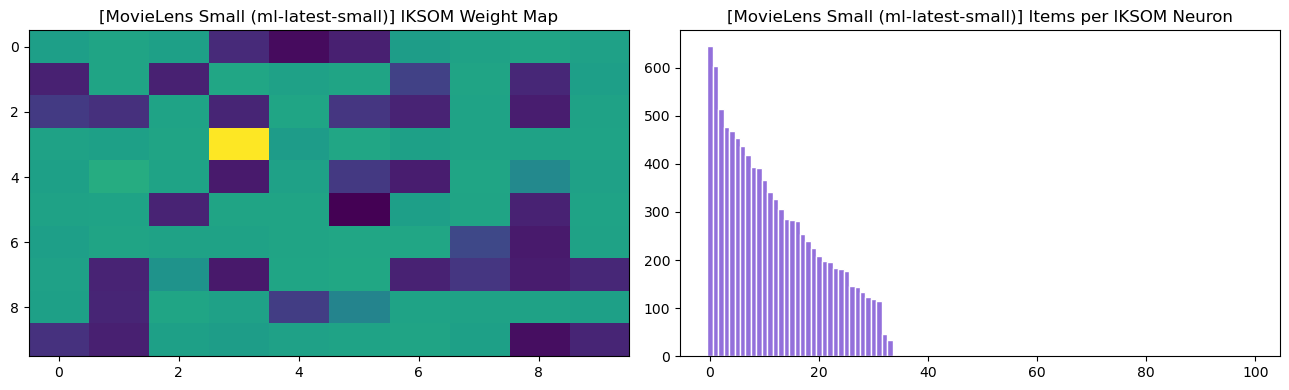

[KMeans++] Searching optimal k in range (2, 15) ...
  k=  2  silhouette=0.2171
  k=  3  silhouette=0.2191
  k=  4  silhouette=0.2120
  k=  5  silhouette=0.2147
  k=  6  silhouette=0.2304
  k=  7  silhouette=0.2363
  k=  8  silhouette=0.2210
  k=  9  silhouette=0.2094
  k= 10  silhouette=0.2210
  k= 11  silhouette=0.2260
  k= 12  silhouette=0.2370
  k= 13  silhouette=0.2413
  k= 14  silhouette=0.2465
  k= 15  silhouette=0.2375
[KMeans++] Optimal k=14  silhouette=0.2465


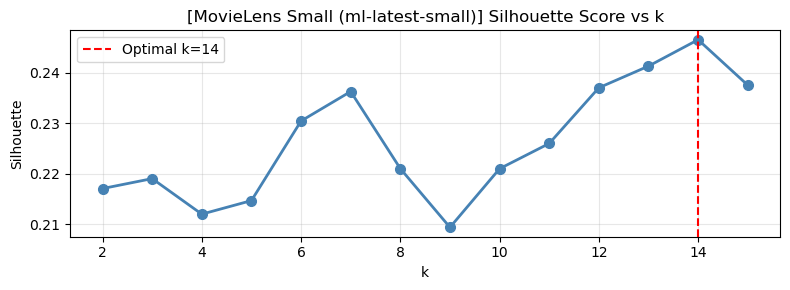


── Final evaluation on TEST set:
[ImprovedSVD] RMSE=0.9264  MAE=0.7142

[HybridRS] Full-Ranking Eval | 606 test users | top-20
  RMSE=0.9264  MAE=0.7142
  Precision=0.0635  Recall=0.0733  F1=0.0681
  Cold users (<20 train ratings): 94
    Cold  Precision=0.0133  Recall=0.0611  F1=0.0218

[MovieLens Small (ml-latest-small)] ✓ Pipeline complete.
  SVD best rank (val-selected): 10
  Val  RMSE=0.9069  MAE=0.7053  (model selection)
  Test RMSE=0.9264  MAE=0.7142  (final report)

  PIPELINE: MovieLens 25M (ml-25m)
  Split: 70% train | 15% val | 15% test
[Data] Subsampling 200,000 from 25,000,095 total ratings
[Data] 200,000 ratings loaded from ratings.csv
[ItemFeatures] 62423 movies | 140-dim features
[Data] Users=80,869 | Items=13,198
[Data] Split → Train=140,000 | Val=30,000 | Test=30,000
[Pipeline] Top-3 popular items (idx): [327, 271, 290]
[ImprovedSVD] fit_with_validation: max_k=50, k_step=5
  rank=  5  val_RMSE=1.1296  ← best
  rank= 10  val_RMSE=1.1296
  rank= 15  val_RMSE=1.1296
  r

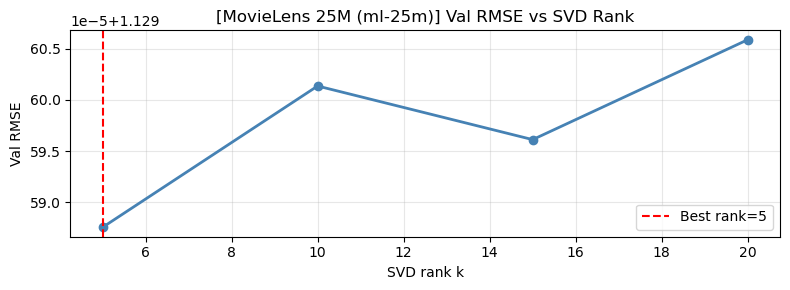

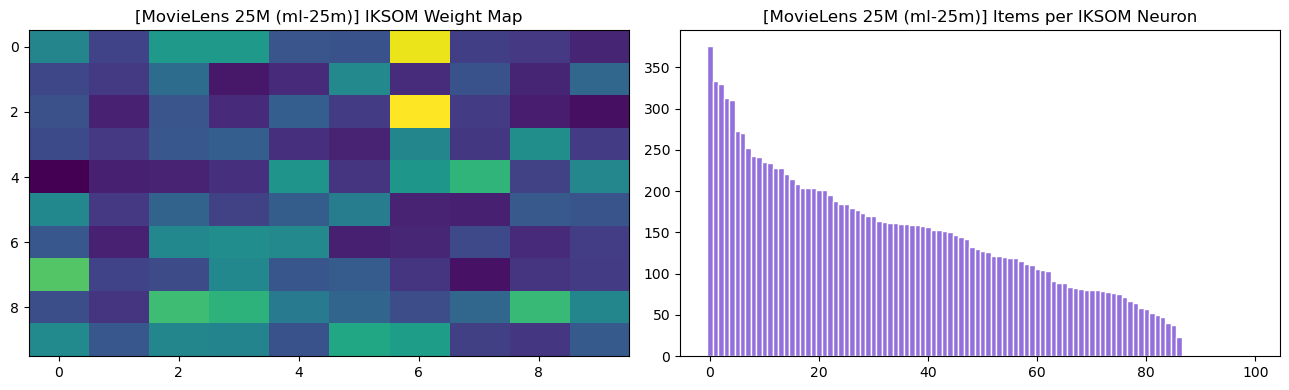

[KMeans++] Searching optimal k in range (2, 15) ...
  k=  2  silhouette=0.1890
  k=  3  silhouette=0.1909
  k=  4  silhouette=0.1938
  k=  5  silhouette=0.1905
  k=  6  silhouette=0.1985
  k=  7  silhouette=0.2006
  k=  8  silhouette=0.1998
  k=  9  silhouette=0.1986
  k= 10  silhouette=0.1878
  k= 11  silhouette=0.1880
  k= 12  silhouette=0.1749
  k= 13  silhouette=0.1817
  k= 14  silhouette=0.1685
  k= 15  silhouette=0.1754
[KMeans++] Optimal k=7  silhouette=0.2006


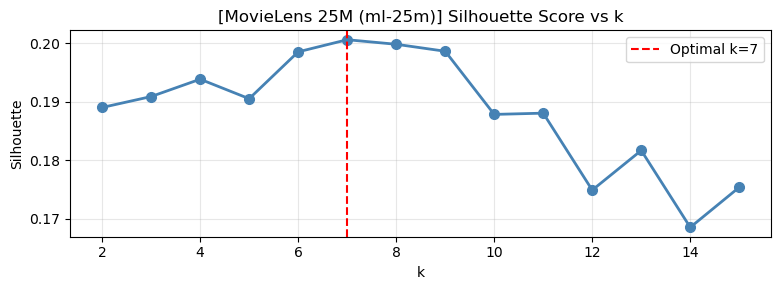


── Final evaluation on TEST set:
[ImprovedSVD] RMSE=1.1361  MAE=0.8714

[HybridRS] Full-Ranking Eval | 23181 test users | top-20
  RMSE=1.1361  MAE=0.8714
  Precision=0.0016  Recall=0.0302  F1=0.0031
  Cold users (<20 train ratings): 23092
    Cold  Precision=0.0016  Recall=0.0303  F1=0.0031

[MovieLens 25M (ml-25m)] ✓ Pipeline complete.
  SVD best rank (val-selected): 5
  Val  RMSE=1.1296  MAE=0.8655  (model selection)
  Test RMSE=1.1361  MAE=0.8714  (final report)

  PIPELINE: MovieLens 1M (ml-1m)
  Split: 70% train | 15% val | 15% test
[Data] DAT layout: 1,000,209 ratings loaded from ratings.dat
[ItemFeatures] DAT layout detected — tags set to zero.
[ItemFeatures] 3883 movies | 140-dim features
[Data] Users=6,040 | Items=3,706
[Data] Split → Train=700,146 | Val=150,031 | Test=150,032
[Pipeline] Top-3 popular items (idx): [2651, 253, 1106]
[ImprovedSVD] fit_with_validation: max_k=50, k_step=5
  rank=  5  val_RMSE=0.9812  ← best
  rank= 10  val_RMSE=0.9739  ← best
  rank= 15  val_RMS

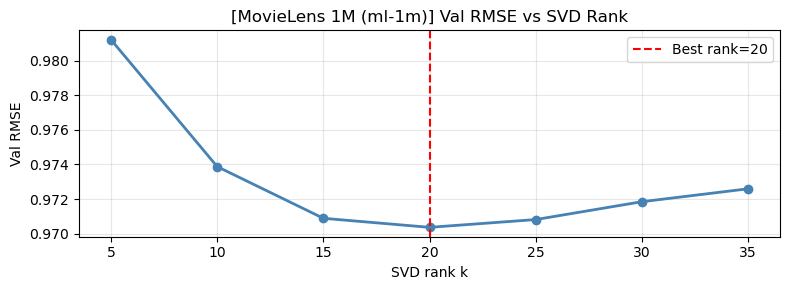

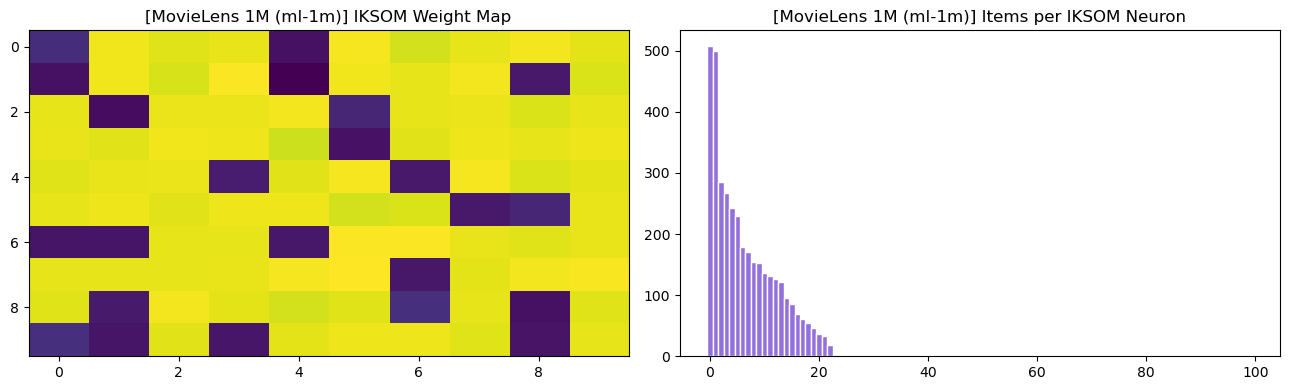

[KMeans++] Searching optimal k in range (2, 15) ...
  k=  2  silhouette=0.2617
  k=  3  silhouette=0.2892
  k=  4  silhouette=0.3097
  k=  5  silhouette=0.3036
  k=  6  silhouette=0.3332
  k=  7  silhouette=0.3660
  k=  8  silhouette=0.3709
  k=  9  silhouette=0.3882
  k= 10  silhouette=0.4070
  k= 11  silhouette=0.4080
  k= 12  silhouette=0.4196
  k= 13  silhouette=0.4347
  k= 14  silhouette=0.4583
  k= 15  silhouette=0.4314
[KMeans++] Optimal k=14  silhouette=0.4583


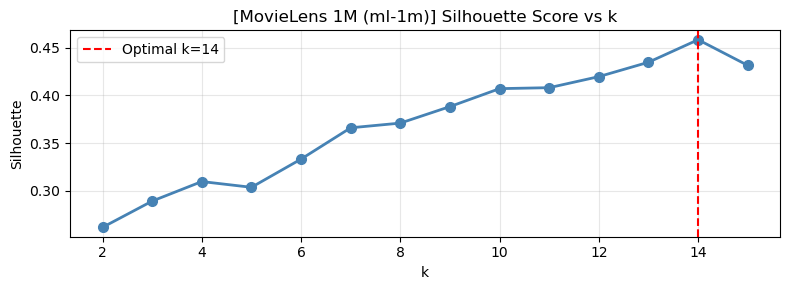


── Final evaluation on TEST set:
[ImprovedSVD] RMSE=0.9674  MAE=0.7668


In [ ]:
# ════════════════════════════════════════════════════════════
#  RUN ON ALL THREE DATASETS
#  This cell trains + evaluates the full hybrid model on
#  Dataset A, Dataset B, and Dataset C sequentially.
#  Each dataset is fully independent (no shared state).
# ════════════════════════════════════════════════════════════

all_results = {}

# ── Dataset A ────────────────────────────────────────────────
metrics_A, data_A, model_A, titles_A, kmeans_A, svd_A = run_pipeline(CONFIG_A, show_plots=True)
all_results[CONFIG_A['name']] = metrics_A

# ── Dataset B ────────────────────────────────────────────────
metrics_B, data_B, model_B, titles_B, kmeans_B, svd_B = run_pipeline(CONFIG_B, show_plots=True)
all_results[CONFIG_B['name']] = metrics_B

# ── Dataset C — MovieLens 1M (.dat format) ──────────────────
metrics_C, data_C, model_C, titles_C, kmeans_C, svd_C = run_pipeline(CONFIG_C, show_plots=True)
all_results[CONFIG_C['name']] = metrics_C

print("\n✓ All three pipelines complete. Run the comparison cells below.")


## 12. Comparison Table  (Dataset A vs B vs C)


In [ ]:
# ════════════════════════════════════════════════════════════
#  COMPARISON TABLE  — Dataset A vs Dataset B vs Dataset C
# ════════════════════════════════════════════════════════════

METRICS = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']
name_A = CONFIG_A['name']
name_B = CONFIG_B['name']
name_C = CONFIG_C['name']

W = 22
header_width = 14 + W * 3 + 6
print('\n' + '=' * header_width)
print(f"{'Metric':<14} {name_A[:W]:>{W}} {name_B[:W]:>{W}} {name_C[:W]:>{W}}")
print('=' * header_width)
for m in METRICS:
    va = all_results[name_A][m]
    vb = all_results[name_B][m]
    vc = all_results[name_C][m]
    print(f"{m:<14} {va:>{W}.4f} {vb:>{W}.4f} {vc:>{W}.4f}")
print('=' * header_width)


## 13. Sampled Evaluation  (1 pos + 99 neg — standard RS protocol)
> **Why:** Ranking across ~9,700 items makes Precision@20 extremely small by construction.
> Candidate sampling (100 items) measures *ranking quality* instead.
> Both protocols are reported side-by-side so results are fully transparent.


In [ ]:
# ════════════════════════════════════════════════════════════
#  FAST SAMPLED EVALUATION — limited users + fewer negatives
#  Metrics: Hit@K, NDCG@K, Precision@K, MRR
# ════════════════════════════════════════════════════════════

KS = (10, 20)

MAX_EVAL_USERS = 1000   # evaluate only 1000 users (huge speedup)
NEGATIVES = 49          # instead of 99 negatives

print('Running sampled evaluation for Dataset A ...')
sampled_A = model_A.evaluate_sampled(
    train_R       = data_A['train_R'],
    test_R        = data_A['test_R'],
    user_test_set = data_A['user_test_set'],
    ks            = KS,
    max_users     = MAX_EVAL_USERS,
    n_neg         = NEGATIVES
)

print('\nRunning sampled evaluation for Dataset B ...')
sampled_B = model_B.evaluate_sampled(
    train_R       = data_B['train_R'],
    test_R        = data_B['test_R'],
    user_test_set = data_B['user_test_set'],
    ks            = KS,
    max_users     = MAX_EVAL_USERS,
    n_neg         = NEGATIVES
)

print('\nRunning sampled evaluation for Dataset C (ML-1M) ...')
sampled_C = model_C.evaluate_sampled(
    train_R       = data_C['train_R'],
    test_R        = data_C['test_R'],
    user_test_set = data_C['user_test_set'],
    ks            = KS,
    max_users     = MAX_EVAL_USERS,
    n_neg         = NEGATIVES
)

# Store results
all_results[name_A]['sampled'] = sampled_A
all_results[name_B]['sampled'] = sampled_B
all_results[name_C]['sampled'] = sampled_C


# ── Side-by-side sampled results ─────────────────────────────
print(f"\n{'─'*74}")
print("  Sampled Evaluation (1 pos + random negatives)")
print(f"{'─'*74}")

W2 = 14
for key in ['MRR', 'Hit@10', 'NDCG@10', 'Hit@20', 'NDCG@20']:
    va = sampled_A.get(key, 0)
    vb = sampled_B.get(key, 0)
    vc = sampled_C.get(key, 0)

    print(f"{key:<12} {name_A[:W2]:>{W2}}={va:.4f}  {name_B[:W2]:>{W2}}={vb:.4f}  {name_C[:W2]:>{W2}}={vc:.4f}")

print(f"{'─'*74}")


# ── Bar chart comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_pairs = [('Hit@10','Hit@20'), ('NDCG@10','NDCG@20')]
colors = ['steelblue','seagreen','darkorange']

for ax, (m10, m20) in zip(axes, metric_pairs):

    vals_A = [sampled_A.get(m10,0), sampled_A.get(m20,0)]
    vals_B = [sampled_B.get(m10,0), sampled_B.get(m20,0)]
    vals_C = [sampled_C.get(m10,0), sampled_C.get(m20,0)]

    x = np.arange(2)
    w = 0.25

    b1 = ax.bar(x-w, vals_A, w, label=name_A[:16], color=colors[0])
    b2 = ax.bar(x,   vals_B, w, label=name_B[:16], color=colors[1])
    b3 = ax.bar(x+w, vals_C, w, label=name_C[:16], color=colors[2])

    ax.set_xticks(x)
    ax.set_xticklabels([m10, m20])
    ax.set_ylabel("Score")
    ax.set_title(f"{m10} vs {m20}")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Sampled Evaluation — All Datasets")
plt.tight_layout()

plt.savefig('./sampled_eval_chart.png', dpi=150)
plt.show()

print("Chart saved → ./sampled_eval_chart.png")

## 13. Bar Chart Comparison

In [ ]:
# ════════════════════════════════════════════════════════════
#  BAR CHART — Dataset A vs Dataset B vs Dataset C
# ════════════════════════════════════════════════════════════

name_A = CONFIG_A['name']
name_B = CONFIG_B['name']
name_C = CONFIG_C['name']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
w = 0.22
colors = ['steelblue', 'seagreen', 'darkorange']

def add_bars_3(ax, metrics, labels, datasets):
    x = np.arange(len(metrics))
    for j, (label, vals) in enumerate(zip(labels, datasets)):
        offset = (j - 1) * w
        bars = ax.bar(x + offset, vals, w, label=label, color=colors[j], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# ── Left: Error metrics ───────────────────────────────────────
err_metrics = ['RMSE', 'MAE']
err_A = [all_results[name_A][m] for m in err_metrics]
err_B = [all_results[name_B][m] for m in err_metrics]
err_C = [all_results[name_C][m] for m in err_metrics]
add_bars_3(axes[0], err_metrics,
           [name_A[:18], name_B[:18], name_C[:18]],
           [err_A, err_B, err_C])
axes[0].set_title('Error Metrics (lower = better)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=11)

# ── Right: Ranking metrics ────────────────────────────────────
rank_metrics = ['Precision', 'Recall', 'F1']
rank_A = [all_results[name_A][m] for m in rank_metrics]
rank_B = [all_results[name_B][m] for m in rank_metrics]
rank_C = [all_results[name_C][m] for m in rank_metrics]
add_bars_3(axes[1], rank_metrics,
           [name_A[:18], name_B[:18], name_C[:18]],
           [rank_A, rank_B, rank_C])
axes[1].set_title('Ranking Metrics (higher = better)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=11)

plt.suptitle('Hybrid RS — Three-Dataset Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./comparison_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved → ./comparison_bar_chart.png')


## 14. Radar Chart

In [ ]:
# ════════════════════════════════════════════════════════════
#  RADAR CHART — Dataset A vs Dataset B vs Dataset C
# ════════════════════════════════════════════════════════════

name_A  = CONFIG_A['name']
name_B  = CONFIG_B['name']
name_C  = CONFIG_C['name']
METRICS = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']

def normalise(val, metric):
    if metric in ('RMSE', 'MAE'):
        return max(0.0, 1.0 - val / 2.0)
    return min(float(val), 1.0)

cats   = ['RMSE\n(inv)', 'MAE\n(inv)', 'Precision', 'Recall', 'F1']
N      = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def get_norm(d):
    return [normalise(d[m], m) for m in METRICS]

vals_A = get_norm(all_results[name_A])
vals_B = get_norm(all_results[name_B])
vals_C = get_norm(all_results[name_C])

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for vals, label, color in [
    (vals_A, name_A[:22], 'steelblue'),
    (vals_B, name_B[:22], 'seagreen'),
    (vals_C, name_C[:22], 'darkorange'),
]:
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', lw=2, color=color, label=label)
    ax.fill(angles, v, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), cats, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Normalised Performance Radar\n(1.0 = best possible on each metric)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('./radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved → ./radar_chart.png')


## 15. Sample Recommendations

In [ ]:
# ════════════════════════════════════════════════════════════
#  SAMPLE TOP-10 RECOMMENDATIONS — 2 users per dataset
# ════════════════════════════════════════════════════════════

for cfg, model, data, titles in [
    (CONFIG_A, model_A, data_A, titles_A),
    (CONFIG_B, model_B, data_B, titles_B),
    (CONFIG_C, model_C, data_C, titles_C),
]:
    print(f"\n{'='*65}")
    print(f"  {cfg['name']}")
    print(f"{'='*65}")
    for u in list(data['user_test_set'])[:2]:
        recs     = model.recommend(u, data['R'][u], top_n=10)
        uid_real = data['user_ids'][u]
        rated_n  = int((data['R'][u] > 0).sum())
        pref_cl  = model.kmeans.get_user_preferred_cluster(data['R'][u])
        print(f"\n  User {uid_real}  (rated {rated_n} movies | preferred cluster: {pref_cl})")
        for rank, it in enumerate(recs, 1):
            mid   = data['movie_ids'][it]
            title = titles.get(mid, f'id={mid}')
            score = model.svd.predict(u)[it]
            print(f"    {rank:2d}. {title:<45} [pred={score:.2f}]")


## 16. Visual Analysis  (PCA + Genre Heatmap)

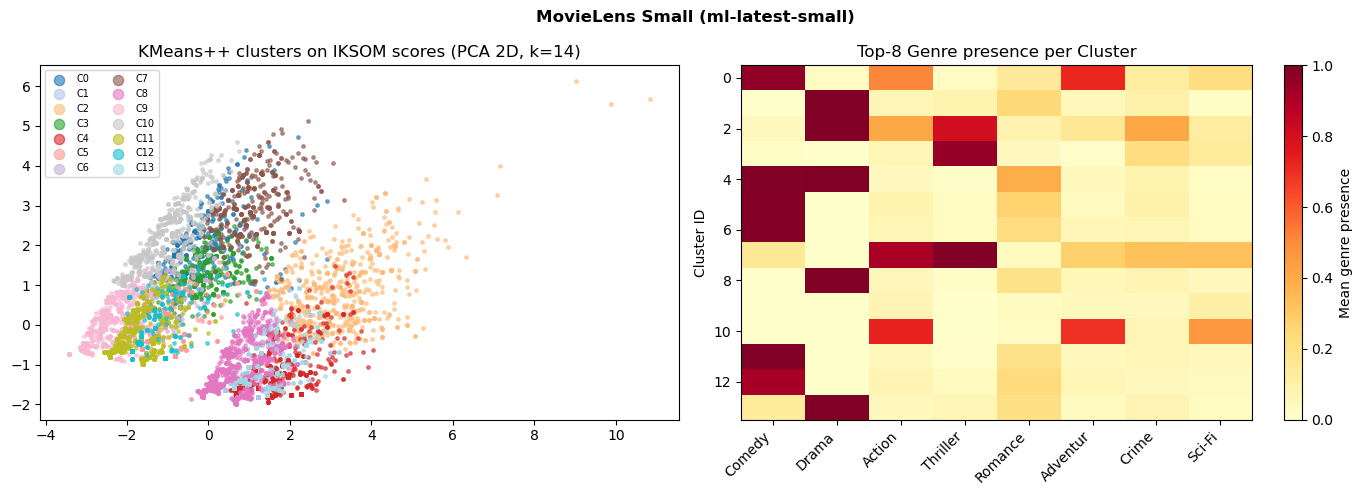

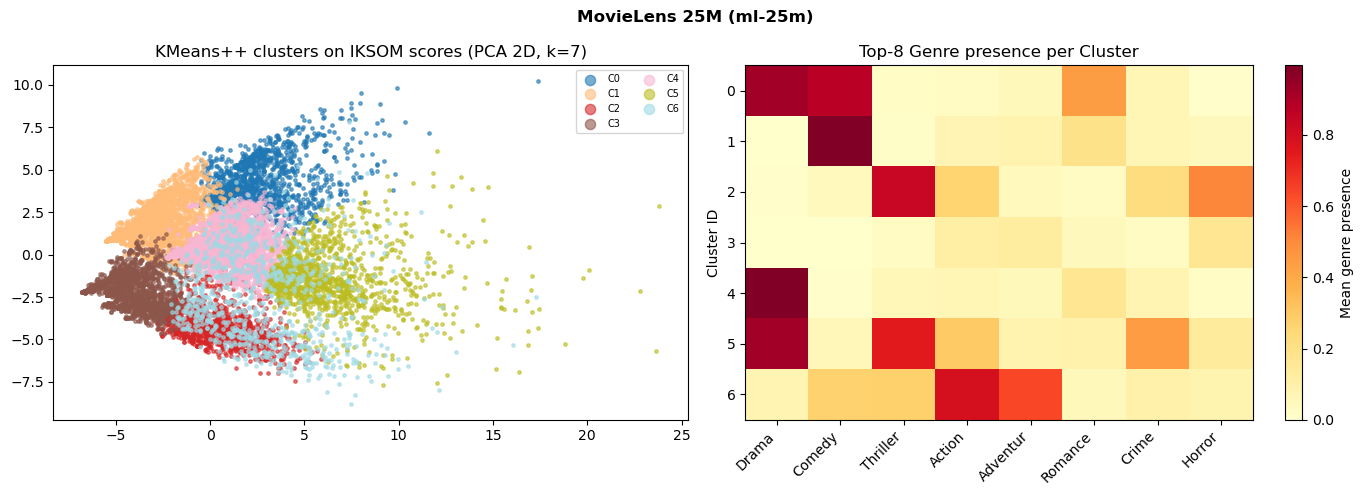

In [ ]:
# ════════════════════════════════════════════════════════════
#  VISUAL ANALYSIS — PCA cluster plot + genre heatmap
#  (one plot per dataset)
# ════════════════════════════════════════════════════════════

for cfg, model, data in [
    (CONFIG_A, model_A, data_A),
    (CONFIG_B, model_B, data_B),
]:
    name    = cfg['name']
    kmeans  = model.kmeans
    _, item_cluster_scores = model.iksom.recall(data['feat'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(name, fontsize=12, fontweight='bold')

    # PCA of IKSOM J-scores coloured by KMeans cluster
    pca  = PCA(n_components=2, random_state=42)
    emb2 = pca.fit_transform(item_cluster_scores)
    cmap = plt.cm.get_cmap('tab20', kmeans.optimal_k)
    for cid in range(kmeans.optimal_k):
        mask = kmeans.labels_ == cid
        axes[0].scatter(emb2[mask, 0], emb2[mask, 1], s=6, alpha=0.6,
                        color=cmap(cid), label=f'C{cid}')
    axes[0].set_title(f'KMeans++ clusters on IKSOM scores (PCA 2D, k={kmeans.optimal_k})')
    axes[0].legend(markerscale=3, fontsize=7, loc='best', ncol=2)

    # Genre heatmap per cluster
    genre_cl = np.zeros((kmeans.optimal_k, GENRE_DIM))
    for cid in range(kmeans.optimal_k):
        items = kmeans.get_items_in_cluster(cid)
        if len(items) > 0:
            genre_cl[cid] = data['feat'][items, :GENRE_DIM].mean(axis=0)
    top_genres = genre_cl.mean(axis=0).argsort()[::-1][:8]
    im = axes[1].imshow(genre_cl[:, top_genres], cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=axes[1], label='Mean genre presence')
    axes[1].set_xticks(range(8))
    axes[1].set_xticklabels([GENRE_LIST[i][:8] for i in top_genres], rotation=45, ha='right')
    axes[1].set_ylabel('Cluster ID')
    axes[1].set_title('Top-8 Genre presence per Cluster')

    plt.tight_layout()
    plt.show()


## 17. Save Results (A vs B vs C)


In [ ]:
# ════════════════════════════════════════════════════════════
#  SAVE RESULTS SUMMARY TO FILE
# ════════════════════════════════════════════════════════════

METRICS = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']
name_A  = CONFIG_A['name']
name_B  = CONFIG_B['name']
name_C  = CONFIG_C['name']

out_path = './results_tri_dataset_comparison.txt'
with open(out_path, 'w') as f:
    f.write('Hybrid RS — Tri-Dataset Comparison\n')
    f.write('='*72 + '\n\n')
    W = 22
    f.write(f"{'Metric':<14} {name_A[:W]:>{W}} {name_B[:W]:>{W}} {name_C[:W]:>{W}}\n")
    f.write('-'*72 + '\n')
    for m in METRICS:
        va = all_results[name_A][m]
        vb = all_results[name_B][m]
        vc = all_results[name_C][m]
        f.write(f"{m:<14} {va:>{W}.4f} {vb:>{W}.4f} {vc:>{W}.4f}\n")
    f.write('\n')
    f.write('── Sampled Evaluation (1 pos + 99 neg) ──\n')
    for name, sr in [(name_A, all_results[name_A].get('sampled', {})),
                     (name_B, all_results[name_B].get('sampled', {})),
                     (name_C, all_results[name_C].get('sampled', {}))]:
        f.write(f"  {name[:50]}\n")
        for key in ['MRR', 'Hit@10', 'NDCG@10', 'Hit@20', 'NDCG@20']:
            f.write(f"    {key:<14} {sr.get(key, 0):.4f}\n")
    f.write('\n')
    f.write(f"Dataset A: Users={data_A['n_users']:,} | Items={data_A['n_items']:,} | ")
    f.write(f"Train={data_A['n_train']:,} | Val={data_A['n_val']:,} | Test={data_A['n_test']:,}\n")
    f.write(f"Dataset B: Users={data_B['n_users']:,} | Items={data_B['n_items']:,} | ")
    f.write(f"Train={data_B['n_train']:,} | Val={data_B['n_val']:,} | Test={data_B['n_test']:,}\n")
    f.write(f"Dataset C: Users={data_C['n_users']:,} | Items={data_C['n_items']:,} | ")
    f.write(f"Train={data_C['n_train']:,} | Val={data_C['n_val']:,} | Test={data_C['n_test']:,}\n")

print(f'Results saved → {out_path}')
print('\nAll done! Charts: comparison_bar_chart.png, radar_chart.png, sampled_eval_chart.png')


## 18. Cold-Start Segment Evaluation
Tests the adaptive blending across three user groups:
- **Cold (0–5 ratings):** content-KNN dominates; 0 ratings → pure popularity fallback
- **Lukewarm (6–20 ratings):** linearly blended CF + content
- **Warm (21+ ratings):** CF dominates (standard paper behaviour)


In [ ]:
# ════════════════════════════════════════════════════════════
#  COLD-START EVALUATION
#  Full-ranking AND sampled metrics per user coldness segment.
# ════════════════════════════════════════════════════════════

def evaluate_cold_start_segments(model, data, cfg, segments=None, n_neg=99, seed=42):
    """
    Evaluate both full-ranking and sampled metrics for users grouped
    by number of training ratings (cold / lukewarm / warm).
    """
    if segments is None:
        segments = [('Cold (0–5)', 5), ('Lukewarm (6–20)', 20), ('Warm (21+)', 9_999)]

    rng      = np.random.default_rng(seed)
    top_n    = cfg['top_n']
    train_R  = data['train_R']
    test_R   = data['test_R']
    test_set = data['user_test_set']
    n_items  = train_R.shape[1]

    user_train_counts = {u: int((train_R[u] > 0).sum()) for u in test_set}

    print(f"\n{'─'*74}")
    print(f"  Cold-Start Segment Analysis — {cfg['name'][:40]}")
    print(f"{'─'*74}")
    print(f"{'Segment':<22} {'Users':>5} {'Prec(full)':>11} {'F1(full)':>9} "
          f"{'Hit@10(samp)':>13} {'NDCG@10(samp)':>14} {'Avg α_cf':>9}")
    print(f"{'─'*74}")

    results  = []
    prev_max = -1

    for label, max_n in segments:
        seg_users = [u for u in test_set
                     if prev_max < user_train_counts[u] <= max_n]
        prev_max  = max_n

        if not seg_users:
            print(f"{label:<22} {'0':>5}  (no users)")
            continue

        # Full-ranking metrics
        precs, recs, alphas = [], [], []
        # Sampled metrics
        hits10, ndcgs10 = [], []

        for u in seg_users:
            relevant  = set(np.where(test_R[u] > 0)[0])
            if not relevant: continue

            # Full-ranking
            recs_list = model.recommend(u, train_R[u], top_n=top_n)
            hits_full = len(set(recs_list) & relevant)
            precs.append(hits_full / top_n)
            recs.append(hits_full / len(relevant))
            n = user_train_counts[u]
            alphas.append(min(n / model.cold_start_threshold, 1.0) * model.alpha)

            # Sampled: one pass per positive item
            all_rated = set(np.where(train_R[u] > 0)[0]) | relevant
            neg_pool  = [i for i in range(n_items) if i not in all_rated]
            for pos in list(relevant):
                if len(neg_pool) < n_neg: continue
                negs       = rng.choice(neg_pool, size=n_neg, replace=False).tolist()
                candidates = [pos] + negs
                ranked     = model.score_candidates(u, train_R[u], candidates)
                pos_rank   = ranked.index(pos) + 1
                hits10.append(1 if pos_rank <= 10 else 0)
                ndcgs10.append(1.0 / np.log2(pos_rank + 1) if pos_rank <= 10 else 0.0)

        p    = np.mean(precs)  if precs  else 0
        r    = np.mean(recs)   if recs   else 0
        f1   = 2*p*r/(p+r+1e-8)
        a    = np.mean(alphas) if alphas else 0
        h10  = np.mean(hits10)  if hits10  else 0
        n10  = np.mean(ndcgs10) if ndcgs10 else 0

        print(f"{label:<22} {len(seg_users):>5} {p:>11.4f} {f1:>9.4f} "
              f"{h10:>13.4f} {n10:>14.4f} {a:>9.4f}")
        results.append((label, len(seg_users), p, f1, h10, n10, a))

    print(f"{'─'*74}")
    print('  Prec(full): full-ranking Precision@20 | Hit@10/NDCG@10: sampled protocol')
    return results


# ── Run for all three datasets ───────────────────────────────
seg_results_A = evaluate_cold_start_segments(model_A, data_A, CONFIG_A)
seg_results_B = evaluate_cold_start_segments(model_B, data_B, CONFIG_B)
seg_results_C = evaluate_cold_start_segments(model_C, data_C, CONFIG_C)


# ── Bar chart: Full-ranking F1 vs Sampled Hit@10 per segment ─
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, results, cfg in [
    (axes[0], seg_results_A, CONFIG_A),
    (axes[1], seg_results_B, CONFIG_B),
    (axes[2], seg_results_C, CONFIG_C),
]:
    if not results: continue
    labels  = [r[0] for r in results]
    f1s     = [r[3] for r in results]
    hits    = [r[4] for r in results]
    x       = np.arange(len(labels))
    w       = 0.30
    seg_colors = ['#e74c3c', '#f39c12', '#2ecc71'][:len(labels)]
    b1 = ax.bar(x - w/2, f1s,  w, label='F1 (full ranking)', color='steelblue',  alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + w/2, hits, w, label='Hit@10 (sampled)',  color='darkorange', alpha=0.85, edgecolor='white')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, min(1.0, max(f1s + hits) * 1.4 + 0.05))
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f"{cfg['name'][:35]}\nFull-Ranking F1 vs Sampled Hit@10",
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cold-Start Segments: Full-Ranking vs Sampled Evaluation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./coldstart_segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → ./coldstart_segment_comparison.png')
